# Feedback Outcome Decoding

This notebook reads saved feedback-locked epochs with metadata and compares outcome decodability across task contexts, using `decoding.epoch_io.py`, `window_decoding_utils.py`

In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next(path for path in (cwd, *cwd.parents) if (path / 'scripts' / 'config.py').exists())
SCRIPTS_DIR = REPO_ROOT / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import config
EPOCHS_ROOT = REPO_ROOT / 'output_mne' / 'epochs'

from decoding.decoding_utils.plotting import plot_window_decoding_summary
from decoding.decoding_utils.window_decoding_utils import run_group_decoding_window
from decoding.decoding_utils.epoch_io import get_epochs_path


In [5]:
PIPELINE = 'proposed'
CONTEXTS = ['mid_high', 'high_high']
WINDOW_START = 0.24
WINDOW_END = 0.34
SUBJECTS = sorted(config.SUBJECT_INFO)

subjects_to_run = [
    sid for sid in SUBJECTS
    if get_epochs_path(sid, PIPELINE, 'feedback', root_dir=EPOCHS_ROOT).exists()
]
if not subjects_to_run:
    raise FileNotFoundError('No saved feedback epochs found. Run make_feedback_epochs.ipynb first.')

summary_df, _, _ = run_group_decoding_window(
    subjects_to_run,
    PIPELINE,
    CONTEXTS,
    window_start=WINDOW_START,
    window_end=WINDOW_END,
    root_dir=EPOCHS_ROOT,
)
summary_df


,subject_id,context,n_trials,n_win,n_loss,cv_splits,window_start_sec,window_end_sec,mean_auc,std_auc
0,27,mid_high,67,42,25,5,0.24,0.34,0.615556,0.194232
1,27,high_high,133,77,56,5,0.24,0.34,0.626894,0.116842
2,28,mid_high,53,45,8,5,0.24,0.34,0.611111,0.426730
3,28,high_high,32,27,5,5,0.24,0.34,0.486667,0.119257
4,29,mid_high,56,27,29,5,0.24,0.34,0.393333,0.175436
5,29,high_high,106,52,54,5,0.24,0.34,0.593554,0.122280
6,30,mid_high,62,40,22,5,0.24,0.34,0.366250,0.146549
7,30,high_high,123,61,62,5,0.24,0.34,0.578526,0.120123
8,31,mid_high,64,41,23,5,0.24,0.34,0.751389,0.167579
9,31,high_high,131,95,36,5,0.24,0.34,0.779511,0.048343


context,high_high,mid_high
subject_id,,
27,0.626894,0.615556
28,0.486667,0.611111
29,0.593554,0.393333
30,0.578526,0.366250
31,0.779511,0.751389


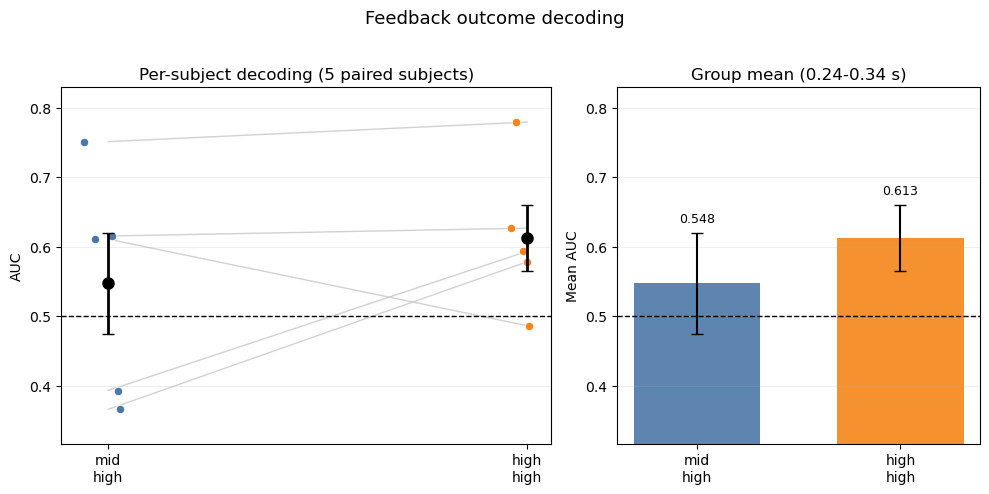

In [6]:
fig, axes, paired_df = plot_window_decoding_summary(
    summary_df,
    CONTEXTS,
    WINDOW_START,
    WINDOW_END,
)
paired_df